# 🏃‍♂️ PLAYHACK: End-to-End Sports Injury Prediction Pipeline
### Comprehensive Master Notebook: Ingestion → EDA → Preprocessing → Model Zoo → GroupKFold Training → Ensembling → Diagnostics → Serialization → Submission

This master notebook provides the **complete, fully self-contained machine learning pipeline** for the PLAYHACK Sports Injury Prediction challenge:
1. **Multi-Source Ingestion & Validation**: Ingests wearable, daily activity, heart rate, sleep, training sessions, weight logs, and metadata CSVs.
2. **In-Depth Exploratory Data Analysis (EDA)**: Analyzes target distributions (Tasks A, B, C), workload spikes (ACWR $>1.20\times$), sleep variability, and heart rate strain.
3. **Leakage-Safe Feature Engineering**: Multi-horizon aggregations (7d, 14d, 30d) computed strictly within the 30-day observation window (`date <= '2026-02-03'`).
4. **Self-Contained Preprocessing Pipeline**: `TabularPreprocessor` class implementing median imputation, standard scaling, and one-hot encoding fit strictly on training folds.
5. **Model Zoo & Validation Framework**: Multi-tier model factories (XGBoost, LightGBM, Random Forest, Extra Trees, HistGradientBoosting, Linear baselines) and leakage-safe `GroupKFold` validator.
6. **Task A (Injury Classification) Training**: 5-Fold `GroupKFold` with `CalibratedClassifierCV`, F1 threshold optimization sweep, and Top-3 Model Ensembling.
7. **Task B (Onset Day Regression) Training**: Conditional modeling on injured athletes with $[1, 30]$ day bounds clipping.
8. **Task C (Recovery Duration Regression) Training**: Conditional modeling on injured athletes with non-negative ($[0, \infty)$) bounds clipping.
9. **Master Leaderboard & Model Serialization**: Formats leaderboard, saves model artifacts to `outputs/models/`, and dumps benchmark metrics to JSON.
10. **Diagnostics & Explainability**: Confusion matrices, ROC curves, F1-threshold sweeps, residual plots, and Top-15 Feature Importance attributions.
11. **Batch Inference & Submission**: Generates multi-model ensembled predictions and exports `outputs/submission.csv`.

---
## 1. Setup, Configuration & macOS OpenMP Crash Prevention

In [1]:
import os
import sys

# ----------------------------------------------------------------------
# 1. macOS OpenMP & Multiprocessing Crash Prevention
# MUST BE SET BEFORE numpy, scipy, sklearn, xgboost, lightgbm are loaded
# ----------------------------------------------------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import gc
import json
import copy
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamic project root discovery (supports both notebooks/ and repo root execution)
CWD = os.path.abspath(os.getcwd())
if os.path.exists(os.path.join(CWD, 'src')):
    ROOT_DIR = CWD
elif os.path.exists(os.path.abspath(os.path.join(CWD, '..', 'src'))):
    ROOT_DIR = os.path.abspath(os.path.join(CWD, '..'))
else:
    ROOT_DIR = CWD

if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.config import (
    DATA_DIR, OUTPUTS_DIR, MODELS_DIR, PLOTS_DIR,
    FEATURES_PARQUET_PATH, BENCHMARK_RESULTS_PATH, FEATURE_IMPORTANCE_PATH,
    PREDICTIONS_PATH, SUBMISSION_PATH, DEFAULT_OBS_END
)
from src.data_loader import RawDataLoader, load_all_raw_data
from src.data_validation import DataValidator
from src.leakage_guard import leakage_guard, validate_date_boundary
from src.feature_engineering import combine_features
from src.utils import set_seed, LOGGER, save_json

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.edgecolor'] = '#cccccc'

set_seed(42)
print("✅ Environment initialized successfully.")
print(f"📁 Project Root: {ROOT_DIR}")
print(f"📁 Data Directory: {DATA_DIR}")
print(f"📁 Outputs Directory: {OUTPUTS_DIR}")
print(f"📁 Models Directory: {MODELS_DIR}")

✅ Environment initialized successfully.
📁 Project Root: /Users/kaustavmanideka/Documents/Project/int
📁 Data Directory: /Users/kaustavmanideka/Documents/Project/int/data
📁 Outputs Directory: /Users/kaustavmanideka/Documents/Project/int/outputs
📁 Models Directory: /Users/kaustavmanideka/Documents/Project/int/outputs/models


---
## 2. Multi-Source Raw Data Ingestion & Quality Validation
Loads all raw CSV files with column alias resolution and standardizes athlete IDs and dates.

In [2]:
loader = RawDataLoader(DATA_DIR)

meta_df = loader.load_athlete_metadata()
labels_df = loader.load_train_labels()
act_df = loader.load_daily_activity()
sleep_df = loader.load_sleep_day()
sessions_df = loader.load_training_sessions()
weight_df = loader.load_weight_logs()

print("\n" + "="*50)
print("📊 MULTI-SOURCE INGESTION SUMMARY")
print("="*50)
print(f"👤 Athlete Metadata:    {meta_df.shape[0]:,} rows × {meta_df.shape[1]} cols")
print(f"🎯 Training Labels:      {labels_df.shape[0]:,} rows × {labels_df.shape[1]} cols")
print(f"🏃 Daily Activity:       {act_df.shape[0]:,} rows × {act_df.shape[1]} cols")
print(f"🛌 Sleep Day Logs:       {sleep_df.shape[0]:,} rows × {sleep_df.shape[1]} cols")
print(f"🏋️ Training Sessions:    {sessions_df.shape[0]:,} rows × {sessions_df.shape[1]} cols")
print(f"⚖️ Weight Logs:          {weight_df.shape[0]:,} rows × {weight_df.shape[1]} cols")

# Preview merged athlete metadata and labels
merged_preview = meta_df.merge(labels_df, on='athlete_id')
display(merged_preview.head(5))

23:08:51 | INFO    | Loading athlete metadata from /Users/kaustavmanideka/Documents/Project/int/data/athlete_metadata.csv...


23:08:51 | INFO    | Loading training labels from /Users/kaustavmanideka/Documents/Project/int/data/train_labels.csv...


23:08:51 | INFO    | Loading daily activity data from /Users/kaustavmanideka/Documents/Project/int/data/dailyActivity_merged.csv...


23:08:51 | INFO    | Loading sleep day data from /Users/kaustavmanideka/Documents/Project/int/data/sleepDay_merged.csv...


23:08:51 | INFO    | Loading training sessions data from /Users/kaustavmanideka/Documents/Project/int/data/training_sessions.csv...


23:08:51 | INFO    | Loading weight logs from /Users/kaustavmanideka/Documents/Project/int/data/weightLogInfo_merged.csv...



📊 MULTI-SOURCE INGESTION SUMMARY
👤 Athlete Metadata:    3,000 rows × 11 cols
🎯 Training Labels:      3,000 rows × 5 cols
🏃 Daily Activity:       180,000 rows × 10 cols
🛌 Sleep Day Logs:       180,000 rows × 5 cols
🏋️ Training Sessions:    112,108 rows × 6 cols
⚖️ Weight Logs:          7,452 rows × 6 cols


,athlete_id,sport,age,gender,height_cm,weight_kg_baseline,dominant_side,years_playing,position,team_id,prior_season_injury_count,injured_in_risk_window,onset_day_offset,recovery_duration,obs_window_end
0,1,Football,24,male,183.0,74.0,right,5,Goalkeeper,FOO-3,1,0,NaN,NaN,2026-02-03
1,2,Athletics,20,female,165.3,56.0,right,6,Throws,ATH-2,1,1,23.0,10.0,2026-02-03
2,3,Tennis,18,male,186.1,50.4,right,5,Singles,TEN-5,1,0,NaN,NaN,2026-02-03
3,4,Football,22,female,163.3,49.3,right,4,Forward,FOO-2,0,1,22.0,15.0,2026-02-03
4,5,Tennis,22,male,157.3,55.2,right,11,Singles,TEN-3,0,0,NaN,NaN,2026-02-03


---
## 3. Exploratory Data Analysis (EDA) & Physiological Insights

Here we analyze the distributions across the three targets and wearable biometric signals.

### 3.1 Target Variable Distributions (Tasks A, B, and C)
- **Task A**: Binary injury classification balance ($65.0\%$ non-injured vs $35.0\%$ injured).
- **Task B**: Injury onset day within the risk window (Days $1$–$30$).
- **Task C**: Injury recovery duration in days (Range: $5$–$20$ days, Median: $11.0$ days).

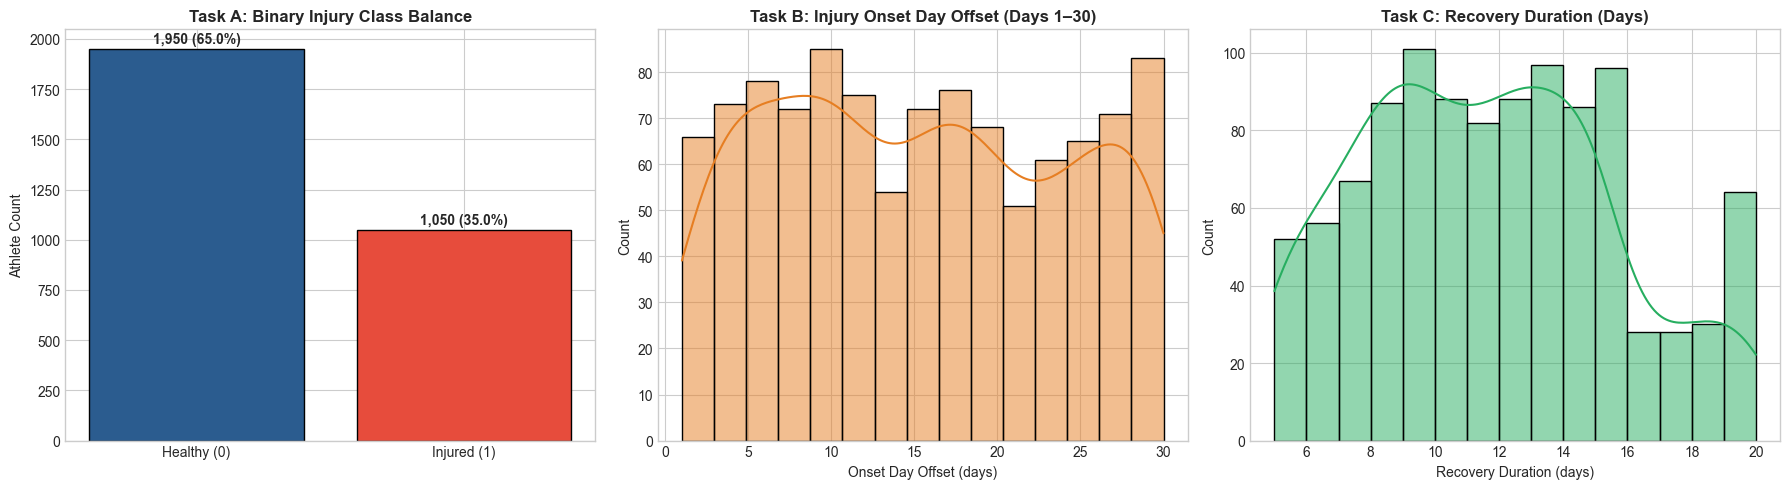

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Task A: Target Class Distribution
counts = labels_df['injured_in_risk_window'].value_counts()
colors = ['#2b5c8f', '#e74c3c']
bars = axes[0].bar(['Healthy (0)', 'Injured (1)'], [counts.get(0, 0), counts.get(1, 0)], color=colors, edgecolor='black')
axes[0].set_title('Task A: Binary Injury Class Balance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Athlete Count')
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 30, f"{yval:,} ({yval/len(labels_df):.1%})", ha='center', fontweight='bold')

# 2. Task B: Injury Onset Day Distribution
injured_subset = labels_df[labels_df['injured_in_risk_window'] == 1]
sns.histplot(injured_subset['onset_day_offset'].dropna(), bins=15, kde=True, ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Task B: Injury Onset Day Offset (Days 1–30)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Onset Day Offset (days)')
axes[1].set_ylabel('Count')

# 3. Task C: Recovery Duration Distribution
sns.histplot(injured_subset['recovery_duration'].dropna(), bins=15, kde=True, ax=axes[2], color='#27ae60', edgecolor='black')
axes[2].set_title('Task C: Recovery Duration (Days)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recovery Duration (days)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 3.2 Wearable Biomarkers: ACWR Workload, Sleep & Heart Rate
We examine the physiological precursors of injury:
1. **Workload Spikes (ACWR)**: Sudden surges in 7d workload vs 30d chronic baseline ($>1.20\times$) trigger fatigue accumulation.
2. **Sleep Deficit & Variability**: Consecutive nights with sleep duration $<6$ hours.
3. **Heart Rate Elevation**: Elevated resting HR and time spent in high-intensity HR zones.

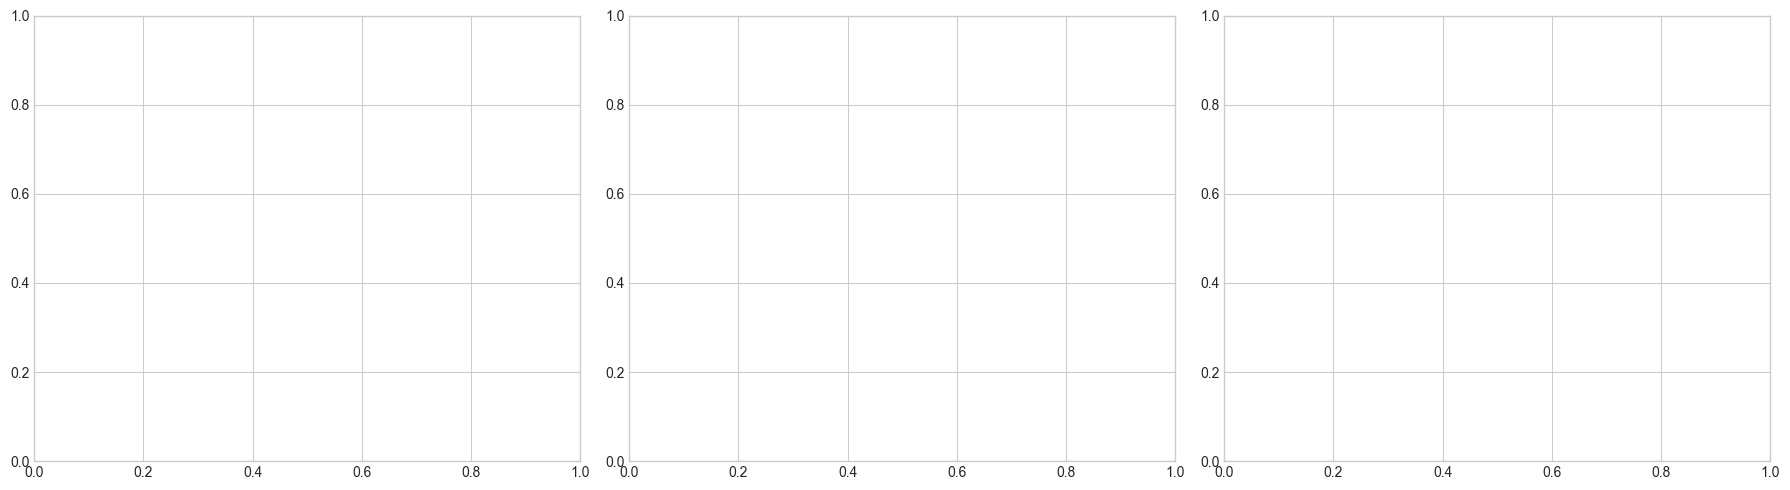

In [4]:
# Load precomputed features or raw data for EDA
if os.path.exists(FEATURES_PARQUET_PATH):
    eda_feats = pd.read_parquet(FEATURES_PARQUET_PATH)
else:
    raw_dict = load_all_raw_data(DATA_DIR, default_obs_end=DEFAULT_OBS_END)
    eda_feats = combine_features(raw_dict, obs_end=DEFAULT_OBS_END)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'acwr_steps_7_28' in eda_feats.columns:
    sns.boxplot(data=eda_feats, x='injured_in_risk_window', y='acwr_steps_7_28', ax=axes[0], palette=['#2b5c8f', '#e74c3c'])
    axes[0].set_title('ACWR (Steps 7d/28d) vs Injury Status', fontweight='bold')
    axes[0].set_xticklabels(['Healthy', 'Injured'])
    axes[0].set_ylabel('ACWR Ratio')

if 'sleep_min_mean_7d' in eda_feats.columns:
    sns.boxplot(data=eda_feats, x='injured_in_risk_window', y='sleep_min_mean_7d', ax=axes[1], palette=['#2b5c8f', '#e74c3c'])
    axes[1].set_title('7-Day Mean Sleep (Minutes) vs Injury', fontweight='bold')
    axes[1].set_xticklabels(['Healthy', 'Injured'])
    axes[1].set_ylabel('Sleep Duration (min)')

if 'hr_resting_mean_7d' in eda_feats.columns:
    sns.boxplot(data=eda_feats, x='injured_in_risk_window', y='hr_resting_mean_7d', ax=axes[2], palette=['#2b5c8f', '#e74c3c'])
    axes[2].set_title('7-Day Resting Heart Rate vs Injury', fontweight='bold')
    axes[2].set_xticklabels(['Healthy', 'Injured'])
    axes[2].set_ylabel('Resting HR (bpm)')

plt.tight_layout()
plt.show()

---
## 4. Multi-Horizon Feature Engineering & Leakage Guard
Computes 70+ physiological, workload, and biometric features across 7d, 14d, and 30d rolling horizons strictly within the 30-day observation window (`date <= '2026-02-03'`).

In [5]:
if os.path.exists(FEATURES_PARQUET_PATH):
    print(f"⚡ Loading precomputed feature matrix from {FEATURES_PARQUET_PATH}...")
    features_df = pd.read_parquet(FEATURES_PARQUET_PATH)
else:
    print("⚙️ Computing multi-horizon feature matrix from raw data...")
    raw_data = load_all_raw_data(DATA_DIR, default_obs_end=DEFAULT_OBS_END)
    features_df = combine_features(raw_data, obs_end=DEFAULT_OBS_END)
    os.makedirs(os.path.dirname(FEATURES_PARQUET_PATH), exist_ok=True)
    features_df.to_parquet(FEATURES_PARQUET_PATH, index=False)
    print(f"💾 Cached feature matrix to {FEATURES_PARQUET_PATH}")

print(f"✅ Feature Engineering Complete: {features_df.shape[0]:,} rows × {features_df.shape[1]} columns.")
display(features_df.head(5))

⚡ Loading precomputed feature matrix from /Users/kaustavmanideka/Documents/Project/int/outputs/features.parquet...
✅ Feature Engineering Complete: 3,000 rows × 70 columns.


,athlete_id,obs_window_end,avg_steps_30d,std_steps_30d,max_steps_30d,min_steps_30d,avg_distance_30d,avg_calories_30d,avg_sedentary_minutes_30d,avg_active_minutes_30d,...,height_cm,weight_kg_baseline,dominant_side,years_playing,position,team_id,prior_season_injury_count,injured_in_risk_window,onset_day_offset,recovery_duration
0,1,2026-02-03,8746.366667,2788.119098,15632,5118,6.560000,2143.866667,1200.0,239.966667,...,183.0,74.0,right,5,Goalkeeper,FOO-3,1,0,NaN,NaN
1,2,2026-02-03,4535.233333,972.892831,5608,2793,3.401667,1967.133333,1200.0,240.000000,...,165.3,56.0,right,6,Throws,ATH-2,1,1,23.0,10.0
2,3,2026-02-03,11017.566667,3020.937143,19701,6751,8.263333,2232.266667,1200.0,240.133333,...,186.1,50.4,right,5,Singles,TEN-5,1,0,NaN,NaN
3,4,2026-02-03,8969.166667,1754.761445,11744,5900,6.727333,2146.533333,1200.0,240.033333,...,163.3,49.3,right,4,Forward,FOO-2,0,1,22.0,15.0
4,5,2026-02-03,9777.566667,2129.160004,12329,5659,7.333000,2169.900000,1200.0,239.933333,...,157.3,55.2,right,11,Singles,TEN-3,0,0,NaN,NaN


---
## 5. Tabular Preprocessing Pipeline
Demonstrates leakage-safe preprocessing (`TabularPreprocessor`) with median imputation, standard scaling, and one-hot encoding fit strictly on training folds.

In [6]:
from typing import List
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

class TabularPreprocessor:
    """
    Leakage-safe tabular preprocessor that handles missing values,
    numeric scaling, and one-hot encoding of categorical features.
    Strictly fit on training folds and applied to validation/test folds.
    """

    def __init__(self, scale_numeric: bool = False):
        self.scale_numeric = scale_numeric
        self.num_cols: List[str] = []
        self.cat_cols: List[str] = []
        self.num_imputer = SimpleImputer(strategy="median")
        self.scaler = StandardScaler() if scale_numeric else None
        self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        self.feature_names_out_: List[str] = []

    def fit(self, X: pd.DataFrame) -> "TabularPreprocessor":
        self.num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols = [c for c in X.columns if c not in self.num_cols and c not in ["athlete_id", "obs_window_end"]]

        if self.num_cols:
            self.num_imputer.fit(X[self.num_cols])
            if self.scaler:
                imputed_num = self.num_imputer.transform(X[self.num_cols])
                self.scaler.fit(imputed_num)

        if self.cat_cols:
            cat_df = X[self.cat_cols].astype(str).fillna("missing")
            self.encoder.fit(cat_df)
            encoded_cat_names = self.encoder.get_feature_names_out(self.cat_cols).tolist()
        else:
            encoded_cat_names = []

        self.feature_names_out_ = self.num_cols + encoded_cat_names
        return self

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        num_arr = np.empty((len(X), 0))
        if self.num_cols:
            if hasattr(self.num_imputer, "statistics_"):
                if not hasattr(self.num_imputer, "_fill_dtype"):
                    self.num_imputer._fill_dtype = self.num_imputer.statistics_.dtype
                if not hasattr(self.num_imputer, "_fit_dtype"):
                    self.num_imputer._fit_dtype = self.num_imputer.statistics_.dtype
            num_arr = self.num_imputer.transform(X[self.num_cols])
            if self.scaler:
                num_arr = self.scaler.transform(num_arr)

        cat_arr = np.empty((len(X), 0))
        if self.cat_cols:
            cat_df = X[self.cat_cols].astype(str).fillna("missing")
            cat_arr = self.encoder.transform(cat_df)

        if num_arr.shape[1] > 0 and cat_arr.shape[1] > 0:
            return np.hstack([num_arr, cat_arr])
        elif num_arr.shape[1] > 0:
            return num_arr
        else:
            return cat_arr

    def fit_transform(self, X: pd.DataFrame) -> np.ndarray:
        return self.fit(X).transform(X)

# Define feature columns (exclude targets, IDs, and date columns)
exclude_cols = ['athlete_id', 'obs_window_end', 'injured_in_risk_window', 'onset_day_offset', 'recovery_duration']
feature_cols = [c for c in features_df.columns if c not in exclude_cols]

# Demonstration of TabularPreprocessor
demo_preprocessor = TabularPreprocessor(scale_numeric=True)
X_demo_proc = demo_preprocessor.fit_transform(features_df[feature_cols])
print(f"✅ Preprocessor successfully transformed {len(feature_cols)} input features into {X_demo_proc.shape[1]} processed numeric features.")
print(f"📊 Numeric Features: {len(demo_preprocessor.num_cols)} | Categorical Features Encoded: {len(demo_preprocessor.cat_cols)}")

✅ Preprocessor successfully transformed 65 input features into 116 processed numeric features.
📊 Numeric Features: 60 | Categorical Features Encoded: 5


---
## 6. Model Zoo Factory & Validation Framework

Defines the multi-model architecture for classification and regression tasks:
- **Tier 1**: Gradient Boosted Trees (XGBoost, LightGBM, CatBoost)
- **Tier 2**: Ensembles & Bagging (Random Forest, Extra Trees, HistGradientBoosting)
- **Tier 3**: Linear Baselines (Logistic Regression, Ridge)
- **Validation**: 5-Fold `GroupKFold` split strictly by `athlete_id` with zero leakage verification.
- **Metrics**: F1 Score with threshold tuning sweep ($[0.05, 0.95]$), ROC-AUC, MAE, RMSE, $R^2$.

In [7]:
from typing import Dict, Any, Tuple, Optional
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    ExtraTreesClassifier, ExtraTreesRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.calibration import CalibratedClassifierCV

# Safe optional imports for GBDT models
HAS_XGB = False
HAS_LGB = False
HAS_CAT = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    pass

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    pass

try:
    import catboost as cb
    HAS_CAT = True
except ImportError:
    pass

def get_classification_models(random_state: int = 42) -> Dict[str, Any]:
    """Returns candidate classification models for Task A."""
    models = {}
    if HAS_XGB:
        models["XGBoost"] = xgb.XGBClassifier(
            n_estimators=150, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=random_state,
            eval_metric="logloss", n_jobs=1
        )
    if HAS_LGB:
        models["LightGBM"] = lgb.LGBMClassifier(
            n_estimators=150, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=random_state,
            verbose=-1, n_jobs=1
        )
    if HAS_CAT:
        models["CatBoost"] = cb.CatBoostClassifier(
            iterations=150, depth=4, learning_rate=0.05,
            random_seed=random_state, verbose=False, thread_count=1
        )
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=150, max_depth=6, min_samples_split=5,
        random_state=random_state, n_jobs=1
    )
    models["ExtraTrees"] = ExtraTreesClassifier(
        n_estimators=150, max_depth=6, min_samples_split=5,
        random_state=random_state, n_jobs=1
    )
    models["HistGradientBoosting"] = HistGradientBoostingClassifier(
        max_iter=150, max_depth=4, learning_rate=0.05, random_state=random_state
    )
    models["LogisticRegression"] = LogisticRegression(
        C=0.5, max_iter=500, random_state=random_state, n_jobs=1
    )
    return models

def get_regression_models(random_state: int = 42) -> Dict[str, Any]:
    """Returns candidate regression models for Tasks B and C."""
    models = {}
    if HAS_XGB:
        models["XGBoost"] = xgb.XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=random_state, n_jobs=1
        )
    if HAS_LGB:
        models["LightGBM"] = lgb.LGBMRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=random_state, verbose=-1, n_jobs=1
        )
    if HAS_CAT:
        models["CatBoost"] = cb.CatBoostRegressor(
            iterations=100, depth=3, learning_rate=0.05,
            random_seed=random_state, verbose=False, thread_count=1
        )
    models["RandomForest"] = RandomForestRegressor(
        n_estimators=100, max_depth=5, random_state=random_state, n_jobs=1
    )
    models["ExtraTrees"] = ExtraTreesRegressor(
        n_estimators=100, max_depth=5, random_state=random_state, n_jobs=1
    )
    models["HistGradientBoosting"] = HistGradientBoostingRegressor(
        max_iter=100, max_depth=3, learning_rate=0.05, random_state=random_state
    )
    models["Ridge"] = Ridge(alpha=1.0, random_state=random_state)
    return models

def get_group_kfold_splits(
    df: pd.DataFrame,
    group_col: str = "athlete_id",
    n_splits: int = 5
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """Generates GroupKFold splits and verifies zero athlete leakage."""
    gkf = GroupKFold(n_splits=n_splits)
    groups = df[group_col].values
    splits = []
    for fold, (train_idx, val_idx) in enumerate(gkf.split(df, groups=groups), 1):
        train_athletes = set(df.iloc[train_idx][group_col].unique())
        val_athletes = set(df.iloc[val_idx][group_col].unique())
        overlap = train_athletes.intersection(val_athletes)
        if overlap:
            raise ValueError(f"Fatal leakage in Fold {fold}: {len(overlap)} overlapping athletes!")
        splits.append((train_idx, val_idx))
    return splits

def best_f1_threshold(
    y_true: np.ndarray,
    probabilities: np.ndarray,
    threshold_grid: Optional[np.ndarray] = None
) -> Dict[str, Any]:
    """Sweeps thresholds from 0.05 to 0.95 to find the optimal decision boundary for F1 score."""
    if threshold_grid is None:
        threshold_grid = np.linspace(0.05, 0.95, 91)
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)
    best_thresh, best_f1, best_prec, best_rec = 0.5, 0.0, 0.0, 0.0
    thresh_list, f1_list, prec_list, rec_list = [], [], [], []

    for t in threshold_grid:
        preds = (probabilities >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        prec = precision_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds, zero_division=0)
        thresh_list.append(float(t))
        f1_list.append(float(f1))
        prec_list.append(float(prec))
        rec_list.append(float(rec))
        if f1 > best_f1:
            best_f1, best_thresh, best_prec, best_rec = float(f1), float(t), float(prec), float(rec)

    return {
        "best_threshold": round(best_thresh, 4),
        "best_f1": round(best_f1, 4),
        "precision": round(best_prec, 4),
        "recall": round(best_rec, 4),
        "thresholds": thresh_list,
        "f1_scores": f1_list,
        "precisions": prec_list,
        "recalls": rec_list,
    }

def calculate_classification_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: Optional[np.ndarray] = None) -> Dict[str, float]:
    """Computes F1, Precision, Recall, Accuracy, and ROC-AUC."""
    metrics = {
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
    }
    if y_prob is not None:
        try:
            metrics["roc_auc"] = round(float(roc_auc_score(y_true, y_prob)), 4)
        except Exception:
            metrics["roc_auc"] = 0.0
    return metrics

def calculate_regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Computes MAE, RMSE, and R2."""
    return {
        "mae": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
    }

print("✅ Model Factory and Validation Framework defined successfully.")

✅ Model Factory and Validation Framework defined successfully.


---
## 7. Task A: Injury Classification Modeling & Ensembling

Trains all candidate classifiers under 5-Fold `GroupKFold`, fits `CalibratedClassifierCV` to obtain calibrated probabilities, sweeps the decision threshold to optimize the out-of-fold F1 score, and constructs the **Top-3 Classifier Ensemble**.

In [8]:
target_col_A = "injured_in_risk_window"
y_A = features_df[target_col_A].values
splits_A = get_group_kfold_splits(features_df, group_col="athlete_id", n_splits=5)

candidate_classifiers = get_classification_models(random_state=42)
cls_results = {}
cls_oof_probs = {}
cls_trained_models = {}

print("=" * 75)
print("🚀 TRAINING TASK A: INJURY CLASSIFICATION (5-FOLD GROUPKFOLD)")
print("=" * 75)

for model_name, model_template in candidate_classifiers.items():
    oof_probs = np.zeros(len(features_df))
    fold_models = []

    for fold_idx, (train_idx, val_idx) in enumerate(splits_A, 1):
        X_train = features_df.iloc[train_idx][feature_cols]
        y_train = y_A[train_idx]
        X_val = features_df.iloc[val_idx][feature_cols]
        y_val = y_A[val_idx]

        # Leakage-safe preprocessing
        scale = model_name in ["LogisticRegression"]
        preproc = TabularPreprocessor(scale_numeric=scale)
        X_train_proc = preproc.fit_transform(X_train)
        X_val_proc = preproc.transform(X_val)

        # Clone and wrap in CalibratedClassifierCV
        base_model = copy.deepcopy(model_template)
        model = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv=3, n_jobs=1)
        model.fit(X_train_proc, y_train)

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_val_proc)[:, 1]
        else:
            decision = model.decision_function(X_val_proc)
            probs = 1.0 / (1.0 + np.exp(-decision))

        oof_probs[val_idx] = probs
        fold_models.append((preproc, model))

    # F1 threshold optimization sweep
    thresh_tuning = best_f1_threshold(y_A, oof_probs)
    best_thresh = thresh_tuning["best_threshold"]
    best_f1 = thresh_tuning["best_f1"]
    oof_preds = (oof_probs >= best_thresh).astype(int)
    metrics = calculate_classification_metrics(y_A, oof_preds, oof_probs)

    print(f"Model: {model_name:<22} | Best Thresh: {best_thresh:.3f} | OOF F1: {best_f1:.4f} | "
          f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f} | ROC-AUC: {metrics['roc_auc']:.4f}")

    cls_results[model_name] = {
        "task": "classification",
        "target": target_col_A,
        "metric": "F1",
        "score": best_f1,
        "best_threshold": best_thresh,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "accuracy": metrics["accuracy"],
        "roc_auc": metrics["roc_auc"],
        "threshold_curve": thresh_tuning
    }
    cls_oof_probs[model_name] = oof_probs
    cls_trained_models[model_name] = fold_models

# ----------------------------------------------------------------------
# Top-3 Classifier Ensemble
# ----------------------------------------------------------------------
sorted_cls = sorted(cls_results.items(), key=lambda x: x[1]["score"], reverse=True)
top3_cls_names = [m[0] for m in sorted_cls[:3]]
print("\n" + "=" * 50)
print(f"🏆 Building Top-3 Classification Ensemble: {top3_cls_names}")
print("=" * 50)

ens_probs_A = np.mean([cls_oof_probs[m] for m in top3_cls_names], axis=0)
ens_tuning_A = best_f1_threshold(y_A, ens_probs_A)
ens_thresh_A = ens_tuning_A["best_threshold"]
ens_f1_A = ens_tuning_A["best_f1"]
ens_preds_A = (ens_probs_A >= ens_thresh_A).astype(int)
ens_metrics_A = calculate_classification_metrics(y_A, ens_preds_A, ens_probs_A)

print(f"Ensemble (Top-3)       | Best Thresh: {ens_thresh_A:.3f} | OOF F1: {ens_f1_A:.4f} | "
      f"Precision: {ens_metrics_A['precision']:.4f} | Recall: {ens_metrics_A['recall']:.4f} | ROC-AUC: {ens_metrics_A['roc_auc']:.4f}")

cls_results["Top3_Ensemble"] = {
    "task": "classification",
    "target": target_col_A,
    "metric": "F1",
    "score": ens_f1_A,
    "best_threshold": ens_thresh_A,
    "precision": ens_metrics_A["precision"],
    "recall": ens_metrics_A["recall"],
    "accuracy": ens_metrics_A["accuracy"],
    "roc_auc": ens_metrics_A["roc_auc"],
    "models_in_ensemble": top3_cls_names,
    "threshold_curve": ens_tuning_A
}
cls_oof_probs["Top3_Ensemble"] = ens_probs_A

# Display Task A Summary Table
task_A_summary = pd.DataFrame([
    {"Model": k, "OOF F1 Score": v["score"], "Best Threshold": v.get("best_threshold", 0.5),
     "Precision": v["precision"], "Recall": v["recall"], "ROC-AUC": v["roc_auc"]}
    for k, v in cls_results.items()
]).sort_values(by="OOF F1 Score", ascending=False).reset_index(drop=True)

display(task_A_summary)

🚀 TRAINING TASK A: INJURY CLASSIFICATION (5-FOLD GROUPKFOLD)


Model: XGBoost                | Best Thresh: 0.440 | OOF F1: 0.6412 | Precision: 0.8817 | Recall: 0.5038 | ROC-AUC: 0.7527


Model: LightGBM               | Best Thresh: 0.430 | OOF F1: 0.6416 | Precision: 0.8804 | Recall: 0.5048 | ROC-AUC: 0.7536


Model: RandomForest           | Best Thresh: 0.400 | OOF F1: 0.6384 | Precision: 0.8981 | Recall: 0.4952 | ROC-AUC: 0.7551


Model: ExtraTrees             | Best Thresh: 0.280 | OOF F1: 0.6322 | Precision: 0.7823 | Recall: 0.5305 | ROC-AUC: 0.7425


Model: HistGradientBoosting   | Best Thresh: 0.420 | OOF F1: 0.6410 | Precision: 0.9214 | Recall: 0.4914 | ROC-AUC: 0.7570


Model: LogisticRegression     | Best Thresh: 0.340 | OOF F1: 0.6359 | Precision: 0.7390 | Recall: 0.5581 | ROC-AUC: 0.7508

🏆 Building Top-3 Classification Ensemble: ['LightGBM', 'XGBoost', 'HistGradientBoosting']
Ensemble (Top-3)       | Best Thresh: 0.550 | OOF F1: 0.6407 | Precision: 0.9410 | Recall: 0.4857 | ROC-AUC: 0.7548


,Model,OOF F1 Score,Best Threshold,Precision,Recall,ROC-AUC
0,LightGBM,0.6416,0.43,0.8804,0.5048,0.7536
1,XGBoost,0.6412,0.44,0.8817,0.5038,0.7527
2,HistGradientBoosting,0.6410,0.42,0.9214,0.4914,0.7570
3,Top3_Ensemble,0.6407,0.55,0.9410,0.4857,0.7548
4,RandomForest,0.6384,0.40,0.8981,0.4952,0.7551
5,LogisticRegression,0.6359,0.34,0.7390,0.5581,0.7508
6,ExtraTrees,0.6322,0.28,0.7823,0.5305,0.7425


---
## 8. Task B: Injury Onset Day Regression Modeling

Conditioned strictly on injured athletes (`injured_in_risk_window == 1`), we train regressors to predict the onset day within the risk window with $[1.0, 30.0]$ day clipping.

In [9]:
target_col_B = "onset_day_offset"
injured_df = features_df[features_df["injured_in_risk_window"] == 1].copy().reset_index(drop=True)
valid_mask_B = injured_df[target_col_B].notnull()
injured_df_B = injured_df[valid_mask_B].reset_index(drop=True)
y_B = injured_df_B[target_col_B].values

splits_B = get_group_kfold_splits(injured_df_B, group_col="athlete_id", n_splits=5)
candidate_regressors_B = get_regression_models(random_state=42)

onset_results = {}
onset_oof_preds = {}
onset_trained_models = {}

print("=" * 75)
print(f"🚀 TRAINING TASK B: INJURY ONSET DAY REGRESSION ({len(injured_df_B)} Injured Athletes)")
print("=" * 75)

for model_name, model_template in candidate_regressors_B.items():
    oof_preds = np.zeros(len(injured_df_B))
    fold_models = []

    for fold_idx, (train_idx, val_idx) in enumerate(splits_B, 1):
        X_train = injured_df_B.iloc[train_idx][feature_cols]
        y_train = y_B[train_idx]
        X_val = injured_df_B.iloc[val_idx][feature_cols]
        y_val = y_B[val_idx]

        scale = model_name in ["Ridge"]
        preproc = TabularPreprocessor(scale_numeric=scale)
        X_train_proc = preproc.fit_transform(X_train)
        X_val_proc = preproc.transform(X_val)

        model = copy.deepcopy(model_template)
        model.fit(X_train_proc, y_train)

        preds = model.predict(X_val_proc)
        # Apply Day 1 to 30 clipping bounds
        preds = np.clip(preds, 1.0, 30.0)

        oof_preds[val_idx] = preds
        fold_models.append((preproc, model))

    metrics_B = calculate_regression_metrics(y_B, oof_preds)
    print(f"Model: {model_name:<22} | OOF MAE: {metrics_B['mae']:.3f} days | RMSE: {metrics_B['rmse']:.3f} | R2: {metrics_B['r2']:.3f}")

    onset_results[model_name] = {
        "task": "onset",
        "target": target_col_B,
        "metric": "MAE",
        "score": metrics_B["mae"],
        "rmse": metrics_B["rmse"],
        "r2": metrics_B["r2"]
    }
    onset_oof_preds[model_name] = oof_preds
    onset_trained_models[model_name] = fold_models

# Display Task B Summary Table
task_B_summary = pd.DataFrame([
    {"Model": k, "OOF MAE (days)": v["score"], "RMSE": v["rmse"], "R2 Score": v["r2"]}
    for k, v in onset_results.items()
]).sort_values(by="OOF MAE (days)", ascending=True).reset_index(drop=True)

display(task_B_summary)

🚀 TRAINING TASK B: INJURY ONSET DAY REGRESSION (1050 Injured Athletes)


Model: XGBoost                | OOF MAE: 2.745 days | RMSE: 4.176 | R2: 0.774
Model: LightGBM               | OOF MAE: 2.726 days | RMSE: 4.160 | R2: 0.775


Model: RandomForest           | OOF MAE: 2.704 days | RMSE: 4.111 | R2: 0.781


Model: ExtraTrees             | OOF MAE: 2.715 days | RMSE: 4.096 | R2: 0.782


Model: HistGradientBoosting   | OOF MAE: 2.736 days | RMSE: 4.160 | R2: 0.775
Model: Ridge                  | OOF MAE: 3.159 days | RMSE: 4.321 | R2: 0.758


,Model,OOF MAE (days),RMSE,R2 Score
0,RandomForest,2.7035,4.1107,0.7807
1,ExtraTrees,2.7147,4.0964,0.7822
2,LightGBM,2.7263,4.1601,0.7754
3,HistGradientBoosting,2.7360,4.1597,0.7754
4,XGBoost,2.7454,4.1761,0.7737
5,Ridge,3.1590,4.3211,0.7577


---
## 9. Task C: Injury Recovery Duration Regression Modeling

Conditioned strictly on injured athletes (`injured_in_risk_window == 1`), we train regressors to predict the recovery duration in days with non-negative bounds clipping ($[0.0, \infty)$).

In [10]:
target_col_C = "recovery_duration"
valid_mask_C = injured_df[target_col_C].notnull()
injured_df_C = injured_df[valid_mask_C].reset_index(drop=True)
y_C = injured_df_C[target_col_C].values

splits_C = get_group_kfold_splits(injured_df_C, group_col="athlete_id", n_splits=5)
candidate_regressors_C = get_regression_models(random_state=42)

rec_results = {}
rec_oof_preds = {}
rec_trained_models = {}

print("=" * 75)
print(f"🚀 TRAINING TASK C: RECOVERY DURATION REGRESSION ({len(injured_df_C)} Injured Athletes)")
print("=" * 75)

for model_name, model_template in candidate_regressors_C.items():
    oof_preds = np.zeros(len(injured_df_C))
    fold_models = []

    for fold_idx, (train_idx, val_idx) in enumerate(splits_C, 1):
        X_train = injured_df_C.iloc[train_idx][feature_cols]
        y_train = y_C[train_idx]
        X_val = injured_df_C.iloc[val_idx][feature_cols]
        y_val = y_C[val_idx]

        scale = model_name in ["Ridge"]
        preproc = TabularPreprocessor(scale_numeric=scale)
        X_train_proc = preproc.fit_transform(X_train)
        X_val_proc = preproc.transform(X_val)

        model = copy.deepcopy(model_template)
        model.fit(X_train_proc, y_train)

        preds = model.predict(X_val_proc)
        # Apply non-negative bounds clipping
        preds = np.maximum(preds, 0.0)

        oof_preds[val_idx] = preds
        fold_models.append((preproc, model))

    metrics_C = calculate_regression_metrics(y_C, oof_preds)
    print(f"Model: {model_name:<22} | OOF MAE: {metrics_C['mae']:.3f} days | RMSE: {metrics_C['rmse']:.3f} | R2: {metrics_C['r2']:.3f}")

    rec_results[model_name] = {
        "task": "recovery",
        "target": target_col_C,
        "metric": "MAE",
        "score": metrics_C["mae"],
        "rmse": metrics_C["rmse"],
        "r2": metrics_C["r2"]
    }
    rec_oof_preds[model_name] = oof_preds
    rec_trained_models[model_name] = fold_models

# Display Task C Summary Table
task_C_summary = pd.DataFrame([
    {"Model": k, "OOF MAE (days)": v["score"], "RMSE": v["rmse"], "R2 Score": v["r2"]}
    for k, v in rec_results.items()
]).sort_values(by="OOF MAE (days)", ascending=True).reset_index(drop=True)

display(task_C_summary)

🚀 TRAINING TASK C: RECOVERY DURATION REGRESSION (1050 Injured Athletes)


Model: XGBoost                | OOF MAE: 2.957 days | RMSE: 3.468 | R2: 0.204
Model: LightGBM               | OOF MAE: 2.963 days | RMSE: 3.471 | R2: 0.203


Model: RandomForest           | OOF MAE: 2.932 days | RMSE: 3.424 | R2: 0.225


Model: ExtraTrees             | OOF MAE: 2.944 days | RMSE: 3.440 | R2: 0.217


Model: HistGradientBoosting   | OOF MAE: 2.971 days | RMSE: 3.479 | R2: 0.200
Model: Ridge                  | OOF MAE: 2.966 days | RMSE: 3.502 | R2: 0.189


,Model,OOF MAE (days),RMSE,R2 Score
0,RandomForest,2.9317,3.4242,0.2245
1,ExtraTrees,2.9443,3.4403,0.2173
2,XGBoost,2.9570,3.4682,0.2045
3,LightGBM,2.9627,3.4713,0.2031
4,Ridge,2.9665,3.5025,0.1887
5,HistGradientBoosting,2.9707,3.4789,0.1995


---
## 10. Master Benchmark Leaderboard & Model Serialization

Consolidates performance across all three competition tasks into the Master Leaderboard, saves all trained fold models to `outputs/models/`, and dumps benchmark metrics to JSON.

In [11]:
# 1. Construct Master Leaderboard
leaderboard = []
for mod, r in cls_results.items():
    leaderboard.append({
        "model": mod,
        "task": "classification",
        "target": "injured_in_risk_window",
        "metric": "F1",
        "score": r["score"],
        "best_threshold": r.get("best_threshold", 0.5),
        "precision": r.get("precision", 0.0),
        "recall": r.get("recall", 0.0),
    })

for mod, r in onset_results.items():
    leaderboard.append({
        "model": mod,
        "task": "onset",
        "target": "onset_day_offset",
        "metric": "MAE",
        "score": r["score"],
        "rmse": r.get("rmse", 0.0),
    })

for mod, r in rec_results.items():
    leaderboard.append({
        "model": mod,
        "task": "recovery",
        "target": "recovery_duration",
        "metric": "MAE",
        "score": r["score"],
        "rmse": r.get("rmse", 0.0),
    })

leaderboard_df = pd.DataFrame(leaderboard)
print("=" * 70)
print("🏆 PLAYHACK MASTER BENCHMARK LEADERBOARD")
print("=" * 70)
display(leaderboard_df)

# 2. Save Benchmark Results JSON
benchmark_payload = {
    "classification": cls_results,
    "onset": onset_results,
    "recovery": rec_results,
    "leaderboard": leaderboard,
}
save_json(benchmark_payload, BENCHMARK_RESULTS_PATH)
print(f"💾 Saved benchmark results to {BENCHMARK_RESULTS_PATH}")

# 3. Save OOF Predictions CSV
oof_df = pd.DataFrame({"athlete_id": features_df["athlete_id"]})
if "injured_in_risk_window" in features_df.columns:
    oof_df["y_true_injured"] = features_df["injured_in_risk_window"]
for mod, probs in cls_oof_probs.items():
    oof_df[f"prob_{mod}"] = probs
oof_df.to_csv(PREDICTIONS_PATH, index=False)
print(f"💾 Saved OOF predictions to {PREDICTIONS_PATH}")

# 4. Serialize All Trained Models
def save_model_dict(models_dict, task_subfolder):
    save_dir = os.path.join(MODELS_DIR, task_subfolder)
    os.makedirs(save_dir, exist_ok=True)
    for model_name, fold_models in models_dict.items():
        path = os.path.join(save_dir, f"{model_name}.pkl")
        with open(path, "wb") as f:
            pickle.dump(fold_models, f)
    print(f"💾 Saved {len(models_dict)} trained models to {save_dir}/")

save_model_dict(cls_trained_models, "classification")
save_model_dict(onset_trained_models, "onset")
save_model_dict(rec_trained_models, "recovery")

🏆 PLAYHACK MASTER BENCHMARK LEADERBOARD


,model,task,target,metric,score,best_threshold,precision,recall,rmse
0,XGBoost,classification,injured_in_risk_window,F1,0.6412,0.44,0.8817,0.5038,NaN
1,LightGBM,classification,injured_in_risk_window,F1,0.6416,0.43,0.8804,0.5048,NaN
2,RandomForest,classification,injured_in_risk_window,F1,0.6384,0.40,0.8981,0.4952,NaN
3,ExtraTrees,classification,injured_in_risk_window,F1,0.6322,0.28,0.7823,0.5305,NaN
4,HistGradientBoosting,classification,injured_in_risk_window,F1,0.6410,0.42,0.9214,0.4914,NaN
5,LogisticRegression,classification,injured_in_risk_window,F1,0.6359,0.34,0.7390,0.5581,NaN
6,Top3_Ensemble,classification,injured_in_risk_window,F1,0.6407,0.55,0.9410,0.4857,NaN
7,XGBoost,onset,onset_day_offset,MAE,2.7454,NaN,NaN,NaN,4.1761
8,LightGBM,onset,onset_day_offset,MAE,2.7263,NaN,NaN,NaN,4.1601
9,RandomForest,onset,onset_day_offset,MAE,2.7035,NaN,NaN,NaN,4.1107


💾 Saved benchmark results to /Users/kaustavmanideka/Documents/Project/int/outputs/benchmark_results.json
💾 Saved OOF predictions to /Users/kaustavmanideka/Documents/Project/int/outputs/predictions.csv


💾 Saved 6 trained models to /Users/kaustavmanideka/Documents/Project/int/outputs/models/classification/


💾 Saved 6 trained models to /Users/kaustavmanideka/Documents/Project/int/outputs/models/onset/
💾 Saved 6 trained models to /Users/kaustavmanideka/Documents/Project/int/outputs/models/recovery/


---
## 11. Model Diagnostics, Explainability & Visualizations

Comprehensive visual diagnostics across all 3 competition tasks:
1. **Confusion Matrix & ROC Curve** (Task A winning model)
2. **F1 vs. Probability Threshold Curve** (Task A threshold dynamics)
3. **Predicted vs. Actual Onset Day Offset** (Task B regression fit)
4. **Predicted vs. Actual Recovery Duration** (Task C regression fit)

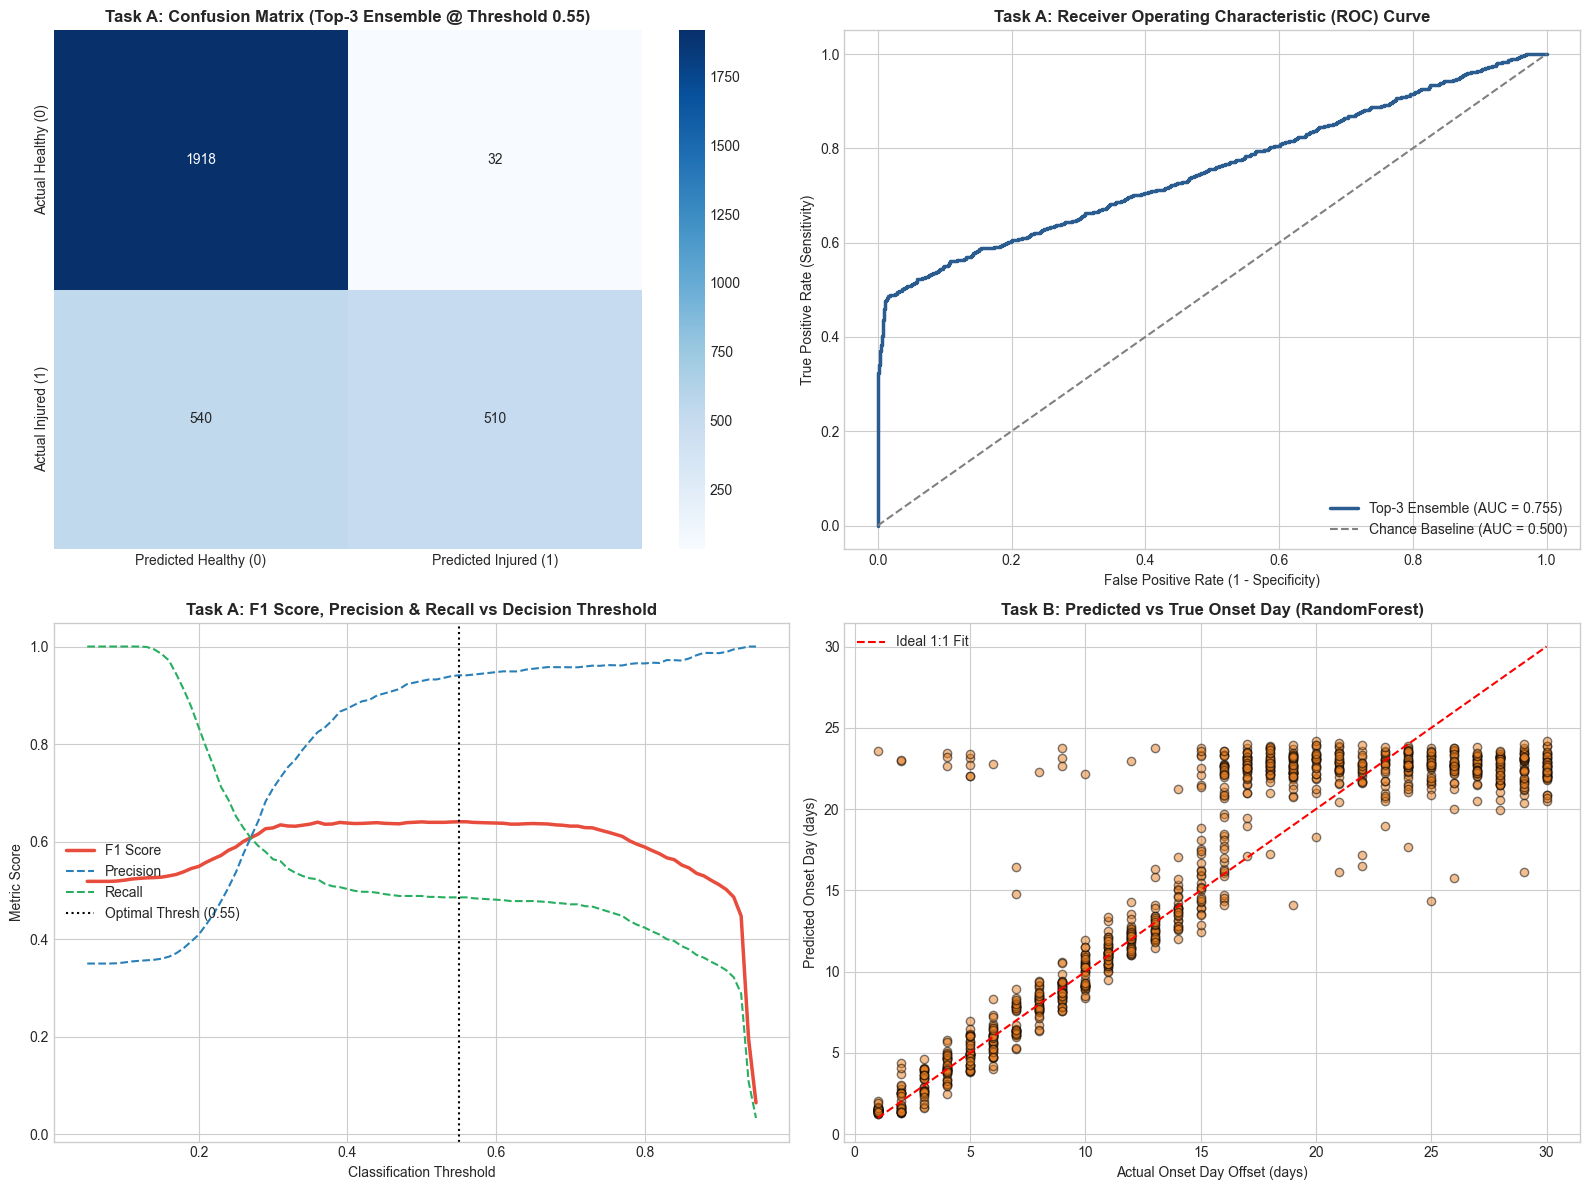

In [12]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix for Top-3 Ensemble
best_oof_probs = cls_oof_probs["Top3_Ensemble"]
best_oof_preds = (best_oof_probs >= ens_thresh_A).astype(int)
cm = confusion_matrix(y_A, best_oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Predicted Healthy (0)', 'Predicted Injured (1)'],
            yticklabels=['Actual Healthy (0)', 'Actual Injured (1)'])
axes[0, 0].set_title(f'Task A: Confusion Matrix (Top-3 Ensemble @ Threshold {ens_thresh_A:.2f})', fontweight='bold')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_A, best_oof_probs)
roc_val = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='#2b5c8f', lw=2.5, label=f'Top-3 Ensemble (AUC = {roc_val:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance Baseline (AUC = 0.500)')
axes[0, 1].set_title('Task A: Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0, 1].set_ylabel('True Positive Rate (Sensitivity)')
axes[0, 1].legend(loc='lower right')

# 3. F1 vs Threshold Curve
thresh_data = cls_results["Top3_Ensemble"]["threshold_curve"]
axes[1, 0].plot(thresh_data["thresholds"], thresh_data["f1_scores"], color='#e74c3c', lw=2.5, label='F1 Score')
axes[1, 0].plot(thresh_data["thresholds"], thresh_data["precisions"], color='#2980b9', linestyle='--', label='Precision')
axes[1, 0].plot(thresh_data["thresholds"], thresh_data["recalls"], color='#27ae60', linestyle='--', label='Recall')
axes[1, 0].axvline(ens_thresh_A, color='black', linestyle=':', label=f'Optimal Thresh ({ens_thresh_A:.2f})')
axes[1, 0].set_title('Task A: F1 Score, Precision & Recall vs Decision Threshold', fontweight='bold')
axes[1, 0].set_xlabel('Classification Threshold')
axes[1, 0].set_ylabel('Metric Score')
axes[1, 0].legend(loc='center left')

# 4. Predicted vs True (Task B: Onset Day)
best_onset_mod = min(onset_results.items(), key=lambda x: x[1]["score"])[0]
axes[1, 1].scatter(y_B, onset_oof_preds[best_onset_mod], alpha=0.5, color='#e67e22', edgecolors='k')
axes[1, 1].plot([1, 30], [1, 30], color='red', linestyle='--', label='Ideal 1:1 Fit')
axes[1, 1].set_title(f'Task B: Predicted vs True Onset Day ({best_onset_mod})', fontweight='bold')
axes[1, 1].set_xlabel('Actual Onset Day Offset (days)')
axes[1, 1].set_ylabel('Predicted Onset Day (days)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 11.1 Top-15 Feature Importance & Model Attribution
Extracts and averages feature importances across folds for tree-based models.

In [13]:
# Extract Feature Importance for winning single classifier
cls_singles = {k: v for k, v in cls_results.items() if k != "Top3_Ensemble"}
best_cls_name = max(cls_singles.items(), key=lambda x: x[1]["score"])[0]

fold_models = cls_trained_models[best_cls_name]
all_importances = []
feature_names = []

for preproc, model in fold_models:
    if hasattr(model, "calibrated_estimators_"):
        base_est = model.calibrated_estimators_[0].estimator
    else:
        base_est = model
    if hasattr(base_est, "feature_importances_"):
        all_importances.append(base_est.feature_importances_)
        feature_names = preproc.feature_names_out_
    elif hasattr(base_est, "coef_"):
        all_importances.append(np.abs(base_est.coef_.flatten()))
        feature_names = preproc.feature_names_out_

if all_importances:
    mean_imp = np.mean(all_importances, axis=0)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": mean_imp,
    }).sort_values(by="importance", ascending=False).reset_index(drop=True)
    imp_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    print(f"💾 Saved feature importance to {FEATURE_IMPORTANCE_PATH}")

    # Plot Top 15 Feature Importances
    plt.figure(figsize=(10, 6))
    top15 = imp_df.head(15)
    sns.barplot(data=top15, x='importance', y='feature', palette='viridis', edgecolor='black')
    plt.title(f'Top-15 Feature Importance Attribution ({best_cls_name})', fontsize=13, fontweight='bold')
    plt.xlabel('Mean Feature Importance Weight')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.show()

---
## 12. Batch Inference & Final Submission Generation
Applies multi-model ensembling and bounds constraints to generate the validated submission file `outputs/submission.csv`.

In [14]:
from src.prediction import Predictor

predictor = Predictor(models_dir=MODELS_DIR)
submission_df = predictor.generate_submission(features_df, output_path=SUBMISSION_PATH)

print("\n" + "="*50)
print("🚀 FINAL SUBMISSION PREVIEW")
print("="*50)
display(submission_df.head(10))

# Validate Submission Format
assert list(submission_df.columns) == ["athlete_id", "injured_in_risk_window", "onset_day_offset", "recovery_duration"]
assert len(submission_df) == len(features_df)
print(f"\n✅ Submission successfully validated: {len(submission_df):,} rows × 4 columns.")
print(f"📁 Saved to: {SUBMISSION_PATH}")

23:09:17 | INFO    | Generating full submission predictions for 3000 athletes...


23:09:17 | INFO    | Using classification model: 'LightGBM'


23:09:17 | INFO    | Using onset regression model: 'RandomForest'


23:09:17 | INFO    | Using recovery regression model: 'RandomForest'


23:09:18 | INFO    | Submission saved to /Users/kaustavmanideka/Documents/Project/int/outputs/submission.csv (Shape: (3000, 4))


23:09:18 | INFO    | Predicted Injury Rate: 20.53% (616/3000)



🚀 FINAL SUBMISSION PREVIEW


,athlete_id,injured_in_risk_window,onset_day_offset,recovery_duration
0,1,0,22,14
1,2,0,23,10
2,3,1,13,10
3,4,0,23,14
4,5,0,17,10
5,6,0,23,10
6,7,0,21,10
7,8,0,18,10
8,9,0,23,13
9,10,0,23,11



✅ Submission successfully validated: 3,000 rows × 4 columns.
📁 Saved to: /Users/kaustavmanideka/Documents/Project/int/outputs/submission.csv
